In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [48]:
df = pd.read_csv("C:/Users/dr274/Downloads/diabetes[1].csv")
cols = ["BloodPressure", "BMI", "Insulin", "SkinThickness"]

for i in cols:
    df[i] = df[i].replace(0, np.nan)
print(df.head())

df_cleaned = df.dropna()


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0           35.0      NaN  33.6   
1            1       85           66.0           29.0      NaN  26.6   
2            8      183           64.0            NaN      NaN  23.3   
3            1       89           66.0           23.0     94.0  28.1   
4            0      137           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Target: Glucose
Features: BMI, Age, Pregnancies, etc.



In [49]:
X = df_cleaned[["Age", "Pregnancies","BloodPressure", "Insulin", "SkinThickness"]]
Y = df_cleaned["BMI"]

#To visualize how the X and Y actually looks like: 
print("This is X:", X.shape)
print("This is Y:", Y.shape)




This is X: (393, 5)
This is Y: (393,)


Text(0, 0.5, 'BMI')

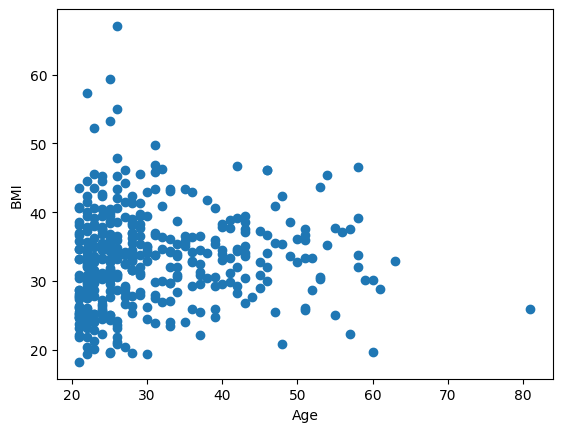

In [50]:
#To better visualize our data we can also plot it using: 
plt.scatter(X["Age"],Y)
plt.xlabel("Age")
plt.ylabel("BMI")

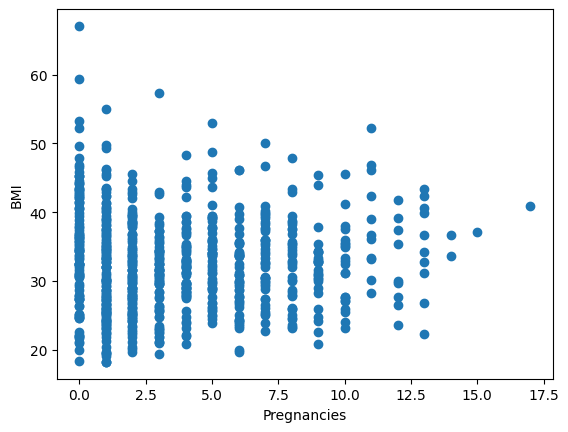

In [42]:
#To better visualize our data we can also plot it using: 
plt.scatter(X["Pregnancies"],Y)
plt.xlabel("Pregnancies")
plt.ylabel("BMI")
plt.show()

Text(0, 0.5, 'BMI')

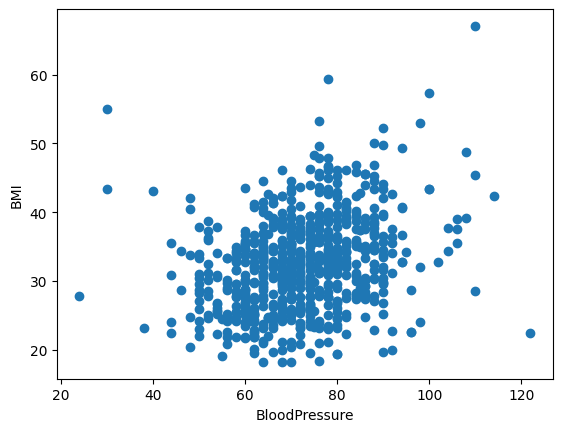

In [17]:
plt.scatter(X["BloodPressure"],Y)
plt.xlabel("BloodPressure")
plt.ylabel("BMI")

To clean our data since there was so many nan values we used: cols = ["BloodPressure", "BMI", "Insulin", "SkinThickness"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)




In [51]:
#After weve graphed our data and weve cleaned it well start with the actual logic of linear regression: 
# Well be using the mean squared error (mse)

def cost_function(w, b, x, y):
    m = x.shape[0]
    cost_sum = 0.0

    for i in range(m):
        f = np.dot(w, x[i]) + b   # dot product
        cost_sum += (f - y[i])**2

    total_cost = cost_sum / (2 * m)

    return total_cost




In [52]:
def gradient(w,b,x,y):
    m_samples = x.shape[0]
    #initializing the parcial derivatives
    dc_dw = np.zeros_like(w)
    dc_db = 0 

    for i in range(m_samples):
        f = np.dot(w, x[i]) + b

        dc_dw += (f - y[i]) * x[i]
        dc_db += (f - y[i])
    
    dc_dw = (1/m_samples) * dc_dw 
    dc_db = (1/m_samples) * dc_db

    return dc_dw, dc_db


In [53]:
def gradient_descent(x,y,learning_rate,itterations):
    #initialize our weights and our biasses 
    w = np.zeros(x.shape[1])
    b = 0 

    for i in range(itterations):
       dc_dw, dc_db = gradient(w,b,x,y)

       w = w - learning_rate * dc_dw
       b = b - learning_rate * dc_db

       print(f"Iteration {i}: cost {cost_function(w,b,x,y)}")
        
    return w,b

    

In [54]:
# The real test: 
# Define our learning rate 

X_np = X.to_numpy()
Y_np = Y.to_numpy()


final_w, final_b = gradient_descent(X_np,Y_np,learning_rate = 0.01,itterations = 1000)

print(f"This is final w: {final_w} and this is finally b: {final_b}")


Iteration 0: cost 76448643.55369842
Iteration 1: cost 14145074122614.242
Iteration 2: cost 2.619299118561076e+18
Iteration 3: cost 4.8502686704430464e+23
Iteration 4: cost 8.98145084581183e+28
Iteration 5: cost 1.6631338339709127e+34
Iteration 6: cost 3.0796963621848304e+39
Iteration 7: cost 5.702806045746277e+44
Iteration 8: cost 1.0560130925481289e+50
Iteration 9: cost 1.9554648057246546e+55
Iteration 10: cost 3.6210181799933426e+60
Iteration 11: cost 6.705194908881674e+65
Iteration 12: cost 1.2416297442112114e+71
Iteration 13: cost 2.2991791329852962e+76
Iteration 14: cost 4.257488764424918e+81
Iteration 15: cost 7.883774830397406e+86
Iteration 16: cost 1.4598724510034752e+92
Iteration 17: cost 2.703308528018259e+97
Iteration 18: cost 5.005832525049029e+102
Iteration 19: cost 9.269515117909396e+107
Iteration 20: cost 1.7164759326483744e+113
Iteration 21: cost 3.1784722176769097e+118
Iteration 22: cost 5.885713540391068e+123
Iteration 23: cost 1.0898828590316221e+129
Iteration 24: co

C:\Users\dr274\AppData\Local\Temp\ipykernel_2236\496891150.py:10: RuntimeWarning: overflow encountered in scalar power
  cost_sum += (f - y[i])**2
C:\Users\dr274\AppData\Local\Temp\ipykernel_2236\2122576044.py:10: RuntimeWarning: overflow encountered in add
  dc_dw += (f - y[i]) * x[i]
C:\Users\dr274\AppData\Local\Temp\ipykernel_2236\2122576044.py:10: RuntimeWarning: invalid value encountered in multiply
  dc_dw += (f - y[i]) * x[i]
C:\Users\dr274\AppData\Local\Temp\ipykernel_2236\3223625336.py:9: RuntimeWarning: invalid value encountered in subtract
  w = w - learning_rate * dc_dw


Iteration 174: cost nan
Iteration 175: cost nan
Iteration 176: cost nan
Iteration 177: cost nan
Iteration 178: cost nan
Iteration 179: cost nan
Iteration 180: cost nan
Iteration 181: cost nan
Iteration 182: cost nan
Iteration 183: cost nan
Iteration 184: cost nan
Iteration 185: cost nan
Iteration 186: cost nan
Iteration 187: cost nan
Iteration 188: cost nan
Iteration 189: cost nan
Iteration 190: cost nan
Iteration 191: cost nan
Iteration 192: cost nan
Iteration 193: cost nan
Iteration 194: cost nan
Iteration 195: cost nan
Iteration 196: cost nan
Iteration 197: cost nan
Iteration 198: cost nan
Iteration 199: cost nan
Iteration 200: cost nan
Iteration 201: cost nan
Iteration 202: cost nan
Iteration 203: cost nan
Iteration 204: cost nan
Iteration 205: cost nan
Iteration 206: cost nan
Iteration 207: cost nan
Iteration 208: cost nan
Iteration 209: cost nan
Iteration 210: cost nan
Iteration 211: cost nan
Iteration 212: cost nan
Iteration 213: cost nan
Iteration 214: cost nan
Iteration 215: c